# **Financial Distress & SC_risk — Regime analysis (code2)**

Extension of `code.ipynb`: **extended sample (2015+)**, **Merton DD clipping**, **regime-conditioned** tables, and **Sharia-compliant long-only** sleeves. The distress spread remains for research; **Halal D10 long-only** is the primary investable sleeve.

Figures save to `figures2/`.

## Setup

Install dependencies and configure the backtest window.

`START = 2015-01-01` includes the 2015–2018 hiking cycle. `FAST_MODE = True` smoke-tests on 60 names. Figures write to `figures2/`.

In [1]:
%pip install -q halalquant yfinance matplotlib requests scipy

import time
import warnings
from datetime import date
from io import StringIO
from pathlib import Path

import requests
from IPython.display import display
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

import halalquant as hq
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from halalquant.providers._yfinance import _map_yahoo_activity, _ticker_info
from halalquant.screening._aaoifi import AAOIFIScreener
from halalquant.screening._sector_filter import SectorFilter
from scipy.stats import rankdata

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams.update({"figure.facecolor": "white", "axes.grid": True, "grid.alpha": 0.3})

# --- Backtest configuration ---
START = "2015-01-01"
END = "2024-12-31"
REBALANCE_FREQ = "QE"           # quarterly, aligned with earnings
DEBT_THRESHOLD = 0.33           # research plan: debt / assets < 33%
FILING_LAG_DAYS = 60            # 45–60 day SEC filing lag
STATUTORY_TAX = 0.21
MERTON_T = 1.0                  # DD horizon (years)
MERTON_RF = 0.02                # risk-free for DD
MERTON_DD_MIN = 0.0               # clip absurd Merton DD inputs
MERTON_DD_MAX = 10.0
LONG_ONLY_LABEL = "Halal D10 long-only"
EXCLUDE_D1_LABEL = "Halal ex-D1 (drop distressed decile)"
HALAL_EW_LABEL = "Halal cohort equal-weight"

HIKE_CALENDAR = [
    ("2015-12-01", "2018-12-31"),
    ("2022-03-01", "2023-07-31"),
]
CUT_CALENDAR = [
    ("2019-08-01", "2021-12-31"),
]
RISK_ON_CALENDAR = [
    ("2023-01-01", "2024-12-31"),
]
N_DECILES = 10
MIN_DECILE_SIZE = 3
FAST_MODE = True
if FAST_MODE:
    N_DECILES = 5
    MIN_DECILE_SIZE = 2
RISK_FREE_RATE = 0.02
COST_BPS = 10
SHORT_BORROW_ANN = 0.05         # illustrative short-leg drag
HALAL_LABEL = "Halal D10 (safe)"
HALAL_DISTRESS_LABEL = "Halal D1 (distressed)"
NON_HALAL_LABEL = "Non-Halal D10 (safe)"
SPREAD_HALAL_LABEL = "Halal D10 − D1 spread (long safe / short distressed)"
SPREAD_NON_HALAL_LABEL = "Non-Halal D10 − D1 spread"

BENCHMARKS = {
    "S&P 500": "SPY",
    "Halal (SPUS)": "SPUS",
}

RATE_HIKE_WINDOWS = [
    ("2004-06-01", "2006-06-30"),
    ("2015-12-01", "2018-12-31"),
    ("2022-03-01", "2023-07-31"),
]

fig_dir = Path.cwd() / "figures2"
if not (Path.cwd() / "code2.ipynb").exists():
    fig_dir = Path.cwd() / "Research" / "papers" / "03-financial-distress" / "figures2"
fig_dir.mkdir(parents=True, exist_ok=True)

print(f"halalquant v{hq.__version__}")
print(f"FAST_MODE={FAST_MODE}  REBALANCE_FREQ={REBALANCE_FREQ}  START={START}")


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
halalquant v0.1.0
FAST_MODE=True  REBALANCE_FREQ=QE  START=2015-01-01


## Step 1 — Start with a universe of stocks

We use **S&P 500 constituents** as the broad US equity universe, then pre-filter excluded business activities (banks, alcohol, gambling, etc.) using `halalquant`'s sector screen. **Halal vs Non-Halal** is determined at each rebalance by AAOIFI financial screens — not by sector alone.

In [2]:
FALLBACK_SP500 = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "BRK-B", "LLY", "AVGO", "JPM",
    "UNH", "XOM", "V", "MA", "PG", "COST", "HD", "JNJ", "ABBV", "NFLX",
    "CRM", "MRK", "AMD", "PEP", "KO", "TMO", "ADBE", "WMT", "CSCO", "ACN",
]


def load_sp500_constituents() -> pd.DataFrame:
    """One Wikipedia fetch: tickers + GICS labels (avoids 500+ Yahoo info calls)."""
    url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
    headers = {"User-Agent": "MontereyFinanceResearch/1.0"}
    try:
        response = requests.get(url, headers=headers, timeout=30)
        response.raise_for_status()
        table = pd.read_html(StringIO(response.text), attrs={"id": "constituents"})[0]
        out = pd.DataFrame(
            {
                "symbol": table["Symbol"].astype(str).str.replace(".", "-", regex=False),
                "gics_sector": table["GICS Sector"].astype(str),
                "gics_industry": table["GICS Sub-Industry"].astype(str),
            }
        )
        return out.drop_duplicates("symbol")
    except Exception as exc:
        print(f"Could not fetch S&P 500 list ({exc}); using fallback basket.")
        return pd.DataFrame(
            {"symbol": FALLBACK_SP500, "gics_sector": "Unclassified", "gics_industry": "Unclassified"}
        )


def _ticker_info_with_retry(symbol: str, max_attempts: int = 4, pause: float = 1.5) -> dict:
    """Yahoo info with backoff — only used when Wikipedia labels are missing."""
    for attempt in range(max_attempts):
        try:
            return _ticker_info(yf.Ticker(symbol))
        except Exception as exc:
            if attempt == max_attempts - 1:
                print(f"  Warning: Yahoo info failed for {symbol} ({exc})")
                return {}
            time.sleep(pause * (attempt + 1))
    return {}


def apply_sector_screen(
    tickers: list[str],
    constituents: pd.DataFrame | None = None,
) -> tuple[list[str], pd.DataFrame, pd.DataFrame]:
    """Sector screen using Wikipedia GICS; Yahoo fallback only for gaps."""
    wiki = constituents.set_index("symbol") if constituents is not None and not constituents.empty else pd.DataFrame()
    sector_map: dict[str, str] = {}
    gics_rows: list[dict] = []
    yahoo_fallback: list[str] = []

    for symbol in tickers:
        if symbol in wiki.index:
            y_sector = str(wiki.at[symbol, "gics_sector"])
            y_industry = str(wiki.at[symbol, "gics_industry"])
        else:
            yahoo_fallback.append(symbol)
            y_sector = ""
            y_industry = ""
        mapped = _map_yahoo_activity(y_sector, y_industry)
        if mapped:
            sector_map[symbol] = mapped
        gics_rows.append(
            {
                "symbol": symbol,
                "gics_sector": y_sector or "Unclassified",
                "gics_industry": y_industry or "Unclassified",
            }
        )

    if yahoo_fallback:
        print(f"  Yahoo fallback for {len(yahoo_fallback)} symbols missing Wikipedia GICS …", flush=True)
        for i, symbol in enumerate(yahoo_fallback, 1):
            if i == 1 or i % 25 == 0 or i == len(yahoo_fallback):
                print(f"    Yahoo info {i}/{len(yahoo_fallback)}", flush=True)
            info = _ticker_info_with_retry(symbol)
            y_sector = str(info.get("sector") or "")
            y_industry = str(info.get("industry") or "")
            mapped = _map_yahoo_activity(y_sector, y_industry)
            if mapped:
                sector_map[symbol] = mapped
            for row in gics_rows:
                if row["symbol"] == symbol:
                    row["gics_sector"] = y_sector or row["gics_sector"]
                    row["gics_industry"] = y_industry or row["gics_industry"]
                    break
            time.sleep(0.15)

    sector_filter = SectorFilter()
    kept = sector_filter.filter_symbols(tickers, sector_map=sector_map)
    audit = pd.DataFrame(sector_filter.audit_log)
    gics = pd.DataFrame(gics_rows).set_index("symbol")
    return kept, audit, gics


constituents = load_sp500_constituents()
raw_universe = constituents["symbol"].tolist()
if FAST_MODE:
    raw_universe = raw_universe[:60]
    print("FAST_MODE is on — smoke-test universe only. Set FAST_MODE = False for the paper.\n")

eligible_universe, sector_audit, gics = apply_sector_screen(raw_universe, constituents)
print(f"Raw universe:      {len(raw_universe)} tickers")
print(f"After sector screen: {len(eligible_universe)} tickers")
print(f"Removed by sector:   {len(raw_universe) - len(eligible_universe)}")
sector_audit.head(10)

FAST_MODE is on — smoke-test universe only. Set FAST_MODE = False for the paper.

Raw universe:      60 tickers
After sector screen: 47 tickers
Removed by sector:   13


,symbol,sector,reason
0,AFL,conventional insurance,excluded business activity
1,ALL,conventional insurance,excluded business activity
2,MO,tobacco,excluded business activity
3,AIG,conventional insurance,excluded business activity
4,AMP,conventional banking,excluded business activity
5,AON,conventional insurance,excluded business activity
6,APO,conventional banking,excluded business activity
7,ACGL,conventional insurance,excluded business activity
8,ARES,conventional banking,excluded business activity
9,AJG,conventional insurance,excluded business activity


## Steps 2–6 — Score SC_risk, split cohorts, build deciles, rebalance

Same pipeline as `code.ipynb`, plus **Merton DD clipping** and correct deciles (**D1 = highest distress**, **D10 = lowest**).

In [3]:
EBIT_ALIASES = ("EBIT", "Operating Income")
PRETAX_ALIASES = ("Pretax Income", "EBT")
TAX_ALIASES = ("Tax Provision", "Tax Expense")
REVENUE_ALIASES = ("Total Revenue", "Operating Revenue")
EQUITY_ALIASES = (
    "Stockholders Equity",
    "Common Stock Equity",
    "Total Equity Gross Minority Interest",
    "Total Stockholder Equity",
)
DEBT_ALIASES = ("Total Debt",)
CASH_ALIASES = (
    "Cash And Cash Equivalents",
    "Cash Cash Equivalents And Short Term Investments",
)
CURRENT_ASSETS_ALIASES = ("Current Assets",)
CURRENT_LIAB_ALIASES = ("Current Liabilities",)
RETAINED_ALIASES = ("Retained Earnings",)
TOTAL_ASSETS_ALIASES = ("Total Assets",)
TOTAL_LIAB_ALIASES = ("Total Liab", "Total Liabilities Net Minority Interest", "Total Liabilities")

DISTRESS_VALUE_COLS = [
    "altman_z", "merton_dd", "sc_risk", "total_assets", "total_liabilities",
    "market_equity", "debt_face", "asset_vol", "ebit", "sales",
]


def _row_key(frame: pd.DataFrame | None, aliases: tuple[str, ...]):
    if frame is None or not isinstance(frame, pd.DataFrame) or frame.empty:
        return None
    lookup = {str(idx).strip().lower(): idx for idx in frame.index}
    for name in aliases:
        hit = lookup.get(name.strip().lower())
        if hit is not None:
            return hit
    return None


def _cell(frame: pd.DataFrame | None, aliases: tuple[str, ...], col) -> float:
    key = _row_key(frame, aliases)
    if key is None or frame is None or col not in frame.columns:
        return np.nan
    val = frame.at[key, col]
    if isinstance(val, pd.Series):
        val = val.dropna()
        if val.empty:
            return np.nan
        val = val.iloc[0]
    try:
        return float(val)
    except (TypeError, ValueError):
        return np.nan


def _aligned_col(frame: pd.DataFrame | None, period_end, tolerance_days: int = 45):
    if frame is None or not isinstance(frame, pd.DataFrame) or frame.empty:
        return None
    target = pd.Timestamp(period_end)
    cols = list(frame.columns)
    diffs = [abs((pd.Timestamp(c) - target).days) for c in cols]
    i = int(np.argmin(diffs))
    return cols[i] if diffs[i] <= tolerance_days else None


def merton_distance_to_default(
    equity_mkt: float,
    debt_face: float,
    equity_vol: float,
    r: float = MERTON_RF,
    T: float = MERTON_T,
) -> tuple[float, float, float]:
    """Iterative Merton DD. Returns (DD, V_A, sigma_A)."""
    if not (np.isfinite(equity_mkt) and equity_mkt > 0 and np.isfinite(debt_face) and debt_face > 0):
        return np.nan, np.nan, np.nan
    if not (np.isfinite(equity_vol) and equity_vol > 0):
        return np.nan, np.nan, np.nan

    from scipy.stats import norm

    V = float(equity_mkt) + float(debt_face)
    sigma_a = float(equity_vol) * float(equity_mkt) / V
    sigma_a = max(sigma_a, 0.05)

    for _ in range(60):
        d1 = (np.log(V / debt_face) + (r + 0.5 * sigma_a ** 2) * T) / (sigma_a * np.sqrt(T))
        d2 = d1 - sigma_a * np.sqrt(T)
        call = V * norm.cdf(d1) - debt_face * np.exp(-r * T) * norm.cdf(d2)
        vega = V * norm.pdf(d1) * np.sqrt(T)
        if vega <= 1e-8:
            break
        sigma_new = float(equity_vol) * float(equity_mkt) / vega
        if not np.isfinite(sigma_new) or sigma_new <= 0:
            break
        if abs(sigma_new - sigma_a) < 1e-5:
            sigma_a = sigma_new
            break
        sigma_a = sigma_new

    dd = (np.log(V / debt_face) + (r + 0.5 * sigma_a ** 2) * T) / (sigma_a * np.sqrt(T))
    return float(dd), float(V), float(sigma_a)


def build_distress_history(symbols: list[str], filing_lag_days: int = FILING_LAG_DAYS) -> pd.DataFrame:
    rows: list[dict] = []
    n_symbols = len(symbols)
    for i, symbol in enumerate(symbols, 1):
        if i == 1 or i % 25 == 0 or i == n_symbols:
            print(f"  Distress history {i}/{n_symbols}", flush=True)
        try:
            ticker = yf.Ticker(symbol)
            income = ticker.income_stmt
            balance = ticker.balance_sheet
            hist = ticker.history(period="5y", auto_adjust=True)
        except Exception:
            continue
        if income is None or balance is None or hist is None or hist.empty:
            continue
        if not isinstance(income, pd.DataFrame) or income.empty:
            continue

        daily_ret = hist["Close"].pct_change().dropna()
        equity_vol = float(daily_ret.tail(252).std() * np.sqrt(252)) if len(daily_ret) >= 60 else np.nan

        for period_end in reversed(list(income.columns)):
            bs_col = _aligned_col(balance, period_end)
            if bs_col is None:
                continue

            ta = _cell(balance, TOTAL_ASSETS_ALIASES, bs_col)
            tl = _cell(balance, TOTAL_LIAB_ALIASES, bs_col)
            ca = _cell(balance, CURRENT_ASSETS_ALIASES, bs_col)
            cl = _cell(balance, CURRENT_LIAB_ALIASES, bs_col)
            re = _cell(balance, RETAINED_ALIASES, bs_col)
            equity_book = _cell(balance, EQUITY_ALIASES, bs_col)
            debt = _cell(balance, DEBT_ALIASES, bs_col)
            cash = _cell(balance, CASH_ALIASES, bs_col)
            ebit = _cell(income, EBIT_ALIASES, period_end)
            sales = _cell(income, REVENUE_ALIASES, period_end)

            if pd.isna(ta) or ta <= 0:
                continue
            if pd.isna(tl) or tl <= 0:
                tl = max(float(ta) - float(equity_book) if pd.notna(equity_book) else np.nan, np.nan)
            if pd.isna(tl) or tl <= 0:
                continue

            wc = np.nan
            if pd.notna(ca) and pd.notna(cl):
                wc = float(ca) - float(cl)
            re_val = 0.0 if pd.isna(re) else float(re)
            ebit_val = 0.0 if pd.isna(ebit) else float(ebit)
            sales_val = np.nan if pd.isna(sales) else float(sales)

            report_ts = pd.Timestamp(period_end).normalize()
            filed_ts = report_ts + pd.Timedelta(days=filing_lag_days)
            hist_local = hist.copy()
            if getattr(hist_local.index, "tz", None) is not None:
                hist_local.index = hist_local.index.tz_localize(None)
            px_hist = hist_local.loc[hist_local.index <= report_ts, "Close"]
            mkt_eq = float(px_hist.iloc[-1]) if not px_hist.empty else np.nan
            if pd.isna(mkt_eq) or mkt_eq <= 0:
                continue

            shares = ticker.info.get("sharesOutstanding") if hasattr(ticker, "info") else None
            try:
                shares = float(shares) if shares else np.nan
            except (TypeError, ValueError):
                shares = np.nan
            market_equity = mkt_eq * shares if pd.notna(shares) and shares > 0 else mkt_eq

            A = wc / ta if pd.notna(wc) else np.nan
            B = re_val / ta
            C = ebit_val / ta
            D = market_equity / tl
            E = sales_val / ta if pd.notna(sales_val) else np.nan
            parts = [A, B, C, D, E]
            altman_z = np.nan
            if all(pd.notna(p) for p in parts):
                altman_z = 1.2 * A + 1.4 * B + 3.3 * C + 0.6 * D + 1.0 * E

            debt_face = float(debt) if pd.notna(debt) and debt > 0 else float(tl)
            dd, v_a, sig_a = merton_distance_to_default(market_equity, debt_face, equity_vol)
            if pd.notna(dd):
                dd = float(np.clip(dd, MERTON_DD_MIN, MERTON_DD_MAX))

            rows.append(
                {
                    "symbol": symbol,
                    "report_date": report_ts.date(),
                    "filed_date": filed_ts.date(),
                    "altman_z": altman_z,
                    "merton_dd": dd,
                    "total_assets": float(ta),
                    "total_liabilities": float(tl),
                    "market_equity": float(market_equity),
                    "debt_face": debt_face,
                    "asset_vol": sig_a,
                    "ebit": ebit_val,
                    "sales": sales_val,
                    "equity_vol": equity_vol,
                }
            )
    return pd.DataFrame(rows)


def attach_latest_distress(metrics: pd.DataFrame, distress_history: pd.DataFrame) -> pd.DataFrame:
    if metrics.empty:
        return metrics.copy()
    out = metrics.drop(columns=[c for c in DISTRESS_VALUE_COLS if c in metrics.columns], errors="ignore").copy()
    if distress_history.empty:
        for col in DISTRESS_VALUE_COLS:
            out[col] = np.nan
        return out

    hist = distress_history.copy()
    hist["filed_date"] = pd.to_datetime(hist["filed_date"])
    hist = hist.sort_values(["symbol", "filed_date"])
    keep_hist = ["symbol", "filed_date"] + [c for c in DISTRESS_VALUE_COLS if c in hist.columns]
    pieces: list[pd.DataFrame] = []
    for symbol, snap in out.groupby("symbol", sort=False):
        snap = snap.copy()
        snap["_as_of"] = pd.to_datetime(snap["as_of"])
        snap = snap.sort_values("_as_of")
        h = hist.loc[hist["symbol"] == symbol, keep_hist]
        if h.empty:
            for col in DISTRESS_VALUE_COLS:
                snap[col] = np.nan
            pieces.append(snap.drop(columns="_as_of"))
            continue
        h = h.rename(columns={"filed_date": "_filed"}).sort_values("_filed")
        merged = pd.merge_asof(snap, h.drop(columns="symbol"), left_on="_as_of", right_on="_filed", direction="backward")
        pieces.append(merged.drop(columns=["_as_of", "_filed"], errors="ignore"))
    return pd.concat(pieces, ignore_index=True)


def add_sc_risk(panel: pd.DataFrame) -> pd.DataFrame:
    """Higher sc_risk = more financial distress (invert Z and DD, then rank-average)."""
    out = panel.copy()
    out["altman_z"] = pd.to_numeric(out.get("altman_z"), errors="coerce")
    out["merton_dd"] = pd.to_numeric(out.get("merton_dd"), errors="coerce")
    out["sc_risk"] = np.nan
    for as_of, grp in out.groupby("as_of", sort=False):
        idx = grp.index
        z = grp["altman_z"]
        dd = grp["merton_dd"]
        valid = z.notna() & dd.notna() & np.isfinite(z) & np.isfinite(dd)
        if valid.sum() < 5:
            continue
        z_rank = rankdata(-z[valid], method="average") / valid.sum()
        dd_rank = rankdata(-dd[valid], method="average") / valid.sum()
        out.loc[idx[valid], "sc_risk"] = 0.5 * z_rank + 0.5 * dd_rank
    return out


def assign_equal_weights(selected: pd.DataFrame) -> pd.DataFrame:
    out = selected.copy()
    if out.empty:
        out["weight"] = pd.Series(dtype=float)
        return out
    out["weight"] = 1.0 / len(out)
    return out


def split_cohorts(snap: pd.DataFrame, screener: AAOIFIScreener) -> tuple[pd.DataFrame, pd.DataFrame]:
    screened = screener.evaluate_compliance(snap)
    merged = snap.drop(columns=[c for c in ("debt_ratio", "cash_ratio", "receivables_ratio", "is_compliant") if c in snap.columns])
    merged = merged.merge(screened, on="symbol", how="inner")
    halal = merged[merged["is_compliant"].fillna(False)].copy()
    non_halal = merged[~merged["is_compliant"].fillna(False)].copy()
    return halal, non_halal


def assign_deciles(cohort: pd.DataFrame, n_deciles: int = N_DECILES) -> pd.DataFrame:
    """Rank by SC_risk: D1 = highest distress, D10 = lowest (matches research-plan.md)."""
    out = cohort.copy()
    out = out[out["sc_risk"].notna() & np.isfinite(out["sc_risk"])].copy()
    if out.empty:
        return out
    n = len(out)
    if n < n_deciles * MIN_DECILE_SIZE:
        return pd.DataFrame()
    # qcut bin 0 = lowest SC_risk → D10; bin n-1 = highest SC_risk → D1
    out["decile"] = n_deciles - pd.qcut(out["sc_risk"], n_deciles, labels=False, duplicates="drop")
    return out


def decile_weights(deciled: pd.DataFrame, decile: int) -> pd.Series:
    chunk = deciled[deciled["decile"] == decile].copy()
    if chunk.empty:
        return pd.Series(dtype=float)
    chunk = assign_equal_weights(chunk)
    return chunk.set_index("symbol")["weight"].astype(float)


def cap_weighted_returns(weights_by_date: dict[date, pd.Series], daily_returns: pd.DataFrame) -> pd.Series:
    rebal = sorted(weights_by_date)
    active_w = pd.Series(dtype=float)
    last: date | None = None
    live = False
    rows: list[float] = []
    for dt in daily_returns.index:
        prior = [d for d in rebal if pd.Timestamp(d) <= dt]
        if prior and prior[-1] != last:
            active_w = weights_by_date.get(prior[-1], pd.Series(dtype=float))
            last = prior[-1]
            if not active_w.empty:
                live = True
        if not live:
            rows.append(np.nan)
            continue
        held = [s for s in active_w.index if s in daily_returns.columns]
        w = active_w.reindex(held).astype(float)
        w = w[w > 0]
        if w.empty:
            rows.append(0.0)
            continue
        w = w / w.sum()
        day_ret = (daily_returns.loc[dt, w.index] * w).sum(skipna=True)
        rows.append(0.0 if pd.isna(day_ret) else float(day_ret))
    return pd.Series(rows, index=pd.to_datetime(daily_returns.index), name="return")


def calc_performance_stats(daily_returns: pd.Series, label: str, rf: float = RISK_FREE_RATE) -> dict:
    r = daily_returns.dropna()
    if r.empty:
        return {"Strategy": label, "CAGR": np.nan, "Volatility": np.nan, "Sharpe": np.nan,
                "Sortino": np.nan, "Max Drawdown": np.nan, "Calmar": np.nan, "Skew": np.nan, "Kurtosis": np.nan}
    equity = (1 + r).cumprod()
    years = len(r) / 252
    cagr = equity.iloc[-1] ** (1 / years) - 1 if years > 0 else np.nan
    vol = r.std() * np.sqrt(252)
    excess = r - rf / 252
    sharpe = excess.mean() / excess.std() * np.sqrt(252) if excess.std() > 0 else np.nan
    downside = r[r < 0]
    sortino = (r.mean() - rf / 252) / downside.std() * np.sqrt(252) if len(downside) else np.nan
    dd = equity / equity.cummax() - 1
    max_dd = dd.min()
    calmar = cagr / abs(max_dd) if max_dd < 0 else np.nan
    return {
        "Strategy": label,
        "CAGR": cagr,
        "Volatility": vol,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Max Drawdown": max_dd,
        "Calmar": calmar,
        "Skew": float(r.skew()),
        "Kurtosis": float(r.kurtosis()),
    }



def classify_regime(as_of: date | pd.Timestamp) -> str:
    """Calendar regimes: rate_hike, rate_cut_zirp, risk_on, neutral."""
    d = pd.Timestamp(as_of)
    for start, end in HIKE_CALENDAR:
        if pd.Timestamp(start) <= d <= pd.Timestamp(end):
            return "rate_hike"
    for start, end in CUT_CALENDAR:
        if pd.Timestamp(start) <= d <= pd.Timestamp(end):
            return "rate_cut_zirp"
    for start, end in RISK_ON_CALENDAR:
        if pd.Timestamp(start) <= d <= pd.Timestamp(end):
            return "risk_on"
    return "neutral"


def regime_table(returns: pd.Series, label: str) -> pd.DataFrame:
    """CAGR / Sharpe / max DD by calendar regime."""
    rows = []
    for name in ["rate_hike", "rate_cut_zirp", "risk_on", "neutral"]:
        mask = [classify_regime(d) == name for d in returns.index]
        sub = returns.iloc[mask].dropna()
        if sub.empty:
            continue
        stats = calc_performance_stats(sub, label)
        stats["Regime"] = name
        stats["Days"] = len(sub)
        rows.append(stats)
    return pd.DataFrame(rows).set_index("Regime") if rows else pd.DataFrame()


def halal_equal_weight_returns(
    snapshots: pd.DataFrame,
    daily_returns: pd.DataFrame,
    cohort: str = "halal",
) -> pd.Series:
    """Equal-weight full Halal cohort each rebalance (buffer baseline)."""
    weights_by_date: dict[date, pd.Series] = {}
    for as_of, snap in snapshots[snapshots["cohort"] == cohort].groupby("as_of"):
        syms = snap["symbol"].unique()
        if len(syms):
            weights_by_date[as_of] = pd.Series(1.0 / len(syms), index=syms)
    return cap_weighted_returns(weights_by_date, daily_returns)


def exclude_decile_returns(
    snapshots: pd.DataFrame,
    daily_returns: pd.DataFrame,
    cohort: str = "halal",
    drop_decile: int = 1,
) -> pd.Series:
    """Long-only: drop highest-distress decile (Sharia-friendly tilt)."""
    weights_by_date: dict[date, pd.Series] = {}
    for as_of, snap in snapshots[snapshots["cohort"] == cohort].groupby("as_of"):
        keep = snap[snap["decile"] != drop_decile]
        if keep.empty:
            continue
        weights_by_date[as_of] = pd.Series(1.0 / len(keep), index=keep["symbol"].unique())
    return cap_weighted_returns(weights_by_date, daily_returns)


def save_fig(name: str):
    plt.tight_layout()
    plt.savefig(fig_dir / name, dpi=160, bbox_inches="tight")
    plt.show()


formatters = {
    "CAGR": "{:.2%}",
    "Volatility": "{:.2%}",
    "Sharpe": "{:.2f}",
    "Sortino": "{:.2f}",
    "Max Drawdown": "{:.2%}",
    "Calmar": "{:.2f}",
    "Skew": "{:.2f}",
    "Kurtosis": "{:.2f}",
}


def build_sc_risk_surface(plot_df: pd.DataFrame, n_grid: int = 40):
    """Interpolate SC_risk for 3D surface plots; nearest fallback when Qhull fails."""
    from scipy.interpolate import griddata

    sub = plot_df.dropna(subset=["altman_z", "merton_dd", "sc_risk"]).copy()
    if len(sub) < 4:
        return None

    pts = sub[["altman_z", "merton_dd"]].values.astype(float)
    vals = sub["sc_risk"].values.astype(float)
    x_min, x_max = pts[:, 0].min(), pts[:, 0].max()
    y_min, y_max = pts[:, 1].min(), pts[:, 1].max()
    pad_x = max(0.05 * (x_max - x_min), 0.1)
    pad_y = max(0.05 * (y_max - y_min), 0.1)
    xi = np.linspace(x_min - pad_x, x_max + pad_x, n_grid)
    yi = np.linspace(y_min - pad_y, y_max + pad_y, n_grid)
    X, Y = np.meshgrid(xi, yi)

    for method in ("linear", "nearest"):
        try:
            Z = griddata(pts, vals, (X, Y), method=method)
            if np.isfinite(Z).sum() >= max(4, int(0.25 * Z.size)):
                return X, Y, Z, method
        except Exception:
            continue
    return None

In [4]:
print("Fetching distress factor history …")
distress_history = build_distress_history(eligible_universe)
print(f"  {distress_history['symbol'].nunique() if not distress_history.empty else 0} symbols with distress data")

print("Fetching point-in-time AAOIFI metrics …")
metrics = hq.get_financial_metrics(eligible_universe, start=START, end=END, freq=REBALANCE_FREQ)
print(f"  {metrics.shape[0]} snapshot rows")

all_symbols = sorted(set(eligible_universe) | set(BENCHMARKS.values()))
print("Downloading price history …")
prices = hq.download(all_symbols, start=START, end=END)
prices["date"] = pd.to_datetime(prices["date"])
print(f"  {prices['symbol'].nunique()} symbols, {prices['date'].nunique()} trading days")

if not distress_history.empty:
    display(
        distress_history.groupby("symbol")[["altman_z", "merton_dd"]]
        .median()
        .describe()
        .style.format("{:.2f}")
        .set_caption("Cross-section of median Altman Z and Merton DD (annual filings)")
    )
metrics.head()

Fetching distress factor history …
  Distress history 1/47
  Distress history 25/47
  Distress history 47/47
  47 symbols with distress data
Fetching point-in-time AAOIFI metrics …
  445 snapshot rows
  49 symbols, 2515 trading days


,altman_z,merton_dd
count,46.00,47.00
mean,4.16,9.98
std,3.47,0.10
min,0.48,9.36
25%,1.58,10.00
50%,3.34,10.00
75%,6.12,10.00
max,17.80,10.00


,symbol,as_of,report_date,filed_date,total_debt,cash_and_equiv,interest_bearing_securities,receivables,liquid_assets,market_cap,market_cap_24m,debt_ratio,cash_ratio,receivables_ratio,total_revenue,non_compliant_income,impure_ratio
0,A,2022-03-31,2021-10-31,2022-01-29,0.000000e+00,0.0,91000000.0,0.000000e+00,91000000.0,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN
1,ADI,2022-03-31,2021-10-31,2022-01-29,5.166630e+08,0.0,0.0,0.000000e+00,0.0,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN
2,AMAT,2022-03-31,2021-10-31,2022-01-29,0.000000e+00,0.0,0.0,4.982000e+09,0.0,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN
3,ABNB,2022-03-31,2021-12-31,2022-03-31,1.983000e+09,0.0,0.0,0.000000e+00,0.0,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN
4,AEE,2022-03-31,2021-12-31,2022-03-31,0.000000e+00,0.0,8000000.0,0.000000e+00,8000000.0,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN


In [5]:
def run_distress_backtest(metrics: pd.DataFrame, distress_history: pd.DataFrame, prices: pd.DataFrame) -> dict:
    panel = add_sc_risk(attach_latest_distress(metrics, distress_history))
    screener = AAOIFIScreener(debt_threshold=DEBT_THRESHOLD)
    price_panel = prices.pivot(index="date", columns="symbol", values="adj_close").sort_index().ffill()
    daily_returns = price_panel.pct_change(fill_method=None)
    rebalance_dates = sorted(pd.to_datetime(panel["as_of"].dropna().unique()).date)

    decile_w: dict[str, dict[int, dict[date, pd.Series]]] = {
        "halal": {d: {} for d in range(1, N_DECILES + 1)},
        "non_halal": {d: {} for d in range(1, N_DECILES + 1)},
    }
    snapshot_log: list[pd.DataFrame] = []

    for as_of in rebalance_dates:
        snap = panel[pd.to_datetime(panel["as_of"]).dt.date == as_of].copy()
        if snap.empty:
            continue
        halal, non_halal = split_cohorts(snap, screener)
        for cohort_name, cohort_df in [("halal", halal), ("non_halal", non_halal)]:
            deciled = assign_deciles(cohort_df)
            if deciled.empty:
                continue
            deciled = deciled.assign(cohort=cohort_name, as_of=as_of)
            snapshot_log.append(deciled)
            for d in range(1, N_DECILES + 1):
                w = decile_weights(deciled, d)
                if not w.empty:
                    decile_w[cohort_name][d][as_of] = w

    snapshots = pd.concat(snapshot_log, ignore_index=True) if snapshot_log else pd.DataFrame()

    def series_for(cohort: str, decile: int) -> pd.Series:
        return cap_weighted_returns(decile_w[cohort][decile], daily_returns)

    halal_d1 = series_for("halal", 1)
    halal_d10 = series_for("halal", N_DECILES)
    non_d1 = series_for("non_halal", 1)
    non_d10 = series_for("non_halal", N_DECILES)

    halal_spread = halal_d10 - halal_d1
    non_spread = non_d10 - non_d1
    halal_spread.name = SPREAD_HALAL_LABEL
    non_spread.name = SPREAD_NON_HALAL_LABEL
    halal_d10 = halal_d10.rename(HALAL_LABEL)
    halal_d1 = halal_d1.rename("Halal D1 (distressed)")
    non_d10 = non_d10.rename(NON_HALAL_LABEL)

    decile_returns = {}
    for cohort in ("halal", "non_halal"):
        for d in range(1, N_DECILES + 1):
            decile_returns[f"{cohort}_D{d}"] = series_for(cohort, d)

    return {
        "panel": panel,
        "snapshots": snapshots,
        "rebalance_dates": rebalance_dates,
        "halal_d1": halal_d1,
        "halal_d10": halal_d10,
        "non_d1": non_d1,
        "non_d10": non_d10,
        "halal_spread": halal_spread,
        "non_spread": non_spread,
        "decile_returns": pd.DataFrame(decile_returns),
        "price_panel": price_panel,
    }


bt = run_distress_backtest(metrics, distress_history, prices[prices["symbol"].isin(eligible_universe)])
panel = bt["panel"]
snapshots = bt["snapshots"]
rebalance_dates = bt["rebalance_dates"]
halal_spread = bt["halal_spread"]
non_spread = bt["non_spread"]
halal_d10 = bt["halal_d10"]
halal_d1 = bt["halal_d1"]
non_d10 = bt["non_d10"]
decile_returns = bt["decile_returns"]
price_panel = bt["price_panel"]

live_halal = halal_spread.dropna()
print(f"Rebalance dates: {len(rebalance_dates)}")
print(f"First Halal spread live day: {live_halal.index.min().date() if not live_halal.empty else 'n/a'}")
print(f"Snapshot rows (deciled names): {len(snapshots)}")
if not snapshots.empty:
    last_as_of = snapshots["as_of"].max()
    last = snapshots[snapshots["as_of"] == last_as_of]
    print(f"Latest rebalance {last_as_of}: Halal={len(last[last['cohort']=='halal'])}  Non-Halal={len(last[last['cohort']=='non_halal'])}")

Rebalance dates: 12
First Halal spread live day: 2023-03-31
Snapshot rows (deciled names): 363
Latest rebalance 2024-12-31: Halal=31  Non-Halal=15


## Step 7 — 3D distress landscape (gradient SC_risk surface)

Latest rebalance: **Altman Z × Merton DD × SC_risk** (plasma / viridis / turbo).

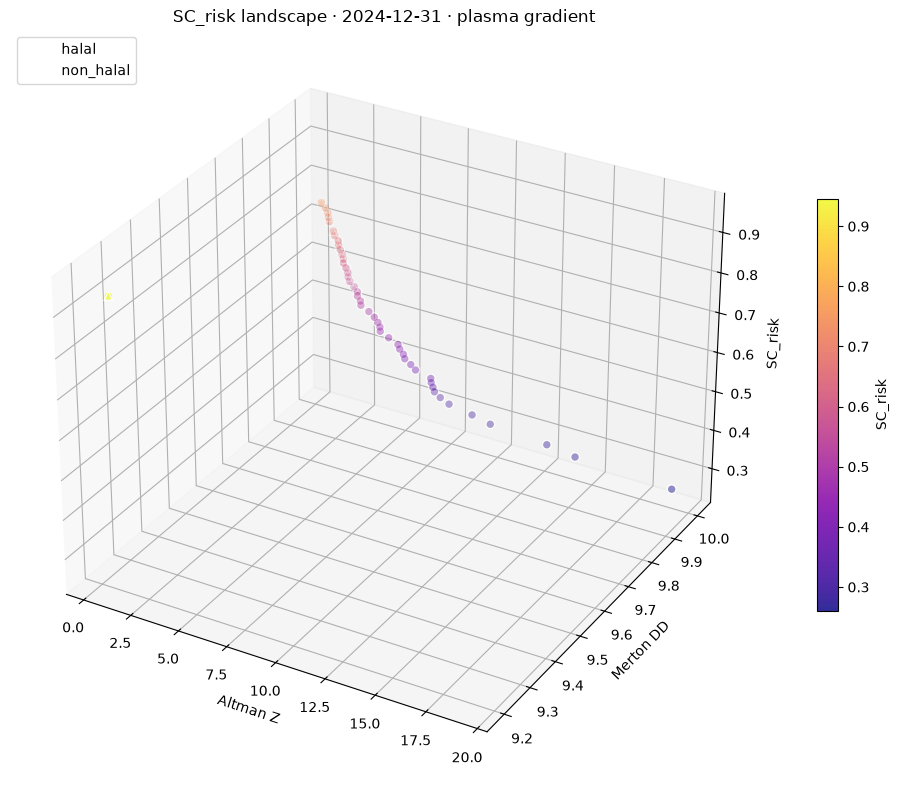

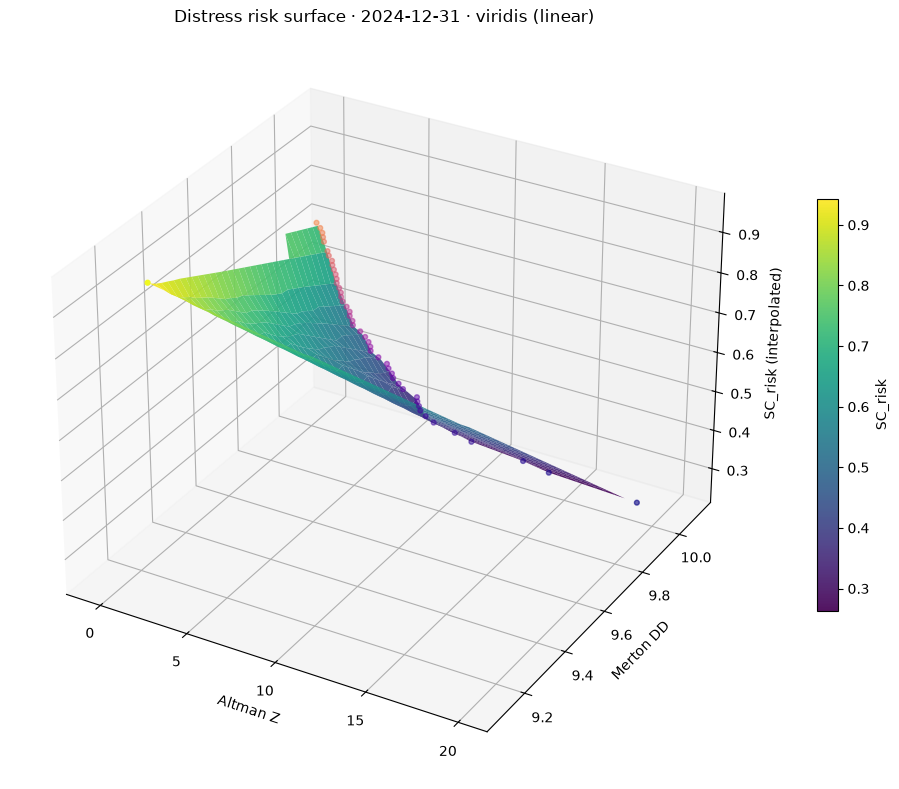

/var/folders/lf/wzrn2w4j7mq_hf01km30xn0c0000gn/T/ipykernel_57969/2974532899.py:82: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/var/folders/lf/wzrn2w4j7mq_hf01km30xn0c0000gn/T/ipykernel_57969/3761805611.py:414: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


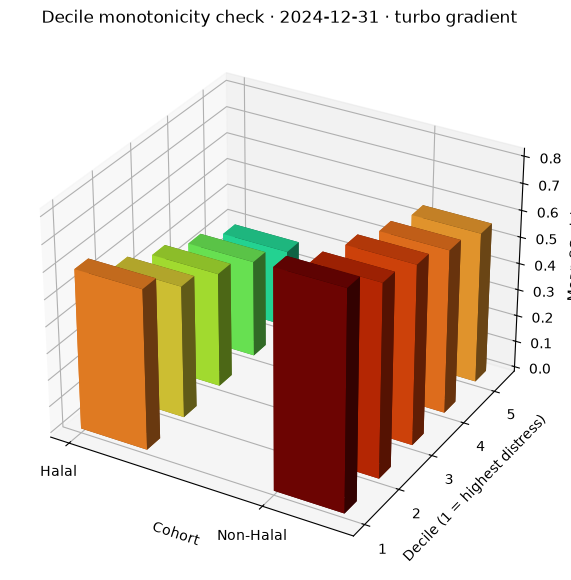

In [6]:
if snapshots.empty:
    print("No decile snapshots — skip 3D plots until backtest produces holdings.")
else:
    last_as_of = snapshots["as_of"].max()
    plot_df = snapshots[snapshots["as_of"] == last_as_of].copy()
    plot_df["debt_to_assets"] = plot_df["debt_ratio"].fillna(
        pd.to_numeric(plot_df.get("total_debt"), errors="coerce") / pd.to_numeric(plot_df.get("total_assets"), errors="coerce")
    )
    plot_df = plot_df.dropna(subset=["altman_z", "merton_dd", "sc_risk"])

    # --- 3D scatter: Z × DD × SC_risk with plasma gradient ---
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection="3d")
    sc = ax.scatter(
        plot_df["altman_z"],
        plot_df["merton_dd"],
        plot_df["sc_risk"],
        c=plot_df["sc_risk"],
        cmap="plasma",
        s=28,
        alpha=0.85,
        edgecolors="none",
    )
    for cohort, marker in ("halal", "o"), ("non_halal", "^"):
        sub = plot_df[plot_df["cohort"] == cohort]
        if not sub.empty:
            ax.scatter(sub["altman_z"], sub["merton_dd"], sub["sc_risk"], marker=marker, s=40, facecolors="none", edgecolors="white", linewidths=0.8, label=cohort)
    ax.set_xlabel("Altman Z")
    ax.set_ylabel("Merton DD")
    ax.set_zlabel("SC_risk")
    ax.set_title(f"SC_risk landscape · {last_as_of} · plasma gradient")
    fig.colorbar(sc, ax=ax, shrink=0.55, label="SC_risk")
    ax.legend(loc="upper left")
    plt.tight_layout()
    save_fig("sc-risk-3d-scatter.png")

    # --- 3D surface: interpolated distress surface (viridis) ---
    surface = build_sc_risk_surface(plot_df)
    if surface is None:
        print(
            f"Skipping 3D surface — only {len(plot_df)} names with Z / DD / SC_risk. "
            "Scatter plot above is still valid; use full universe for a smooth surface."
        )
    else:
        X, Y, Z, interp_method = surface
        fig = plt.figure(figsize=(12, 8))
        ax = fig.add_subplot(111, projection="3d")
        surf = ax.plot_surface(X, Y, Z, cmap="viridis", linewidth=0, antialiased=True, alpha=0.92)
        ax.scatter(
            plot_df["altman_z"], plot_df["merton_dd"], plot_df["sc_risk"],
            c=plot_df["sc_risk"], cmap="plasma", s=12, depthshade=True,
        )
        ax.set_xlabel("Altman Z")
        ax.set_ylabel("Merton DD")
        ax.set_zlabel("SC_risk (interpolated)")
        ax.set_title(f"Distress risk surface · {last_as_of} · viridis ({interp_method})")
        fig.colorbar(surf, ax=ax, shrink=0.55, label="SC_risk")
        plt.tight_layout()
        save_fig("sc-risk-3d-surface.png")

    # --- 3D bar landscape: cohort × decile × mean SC_risk (turbo) ---
    mono = plot_df.groupby(["cohort", "decile"], as_index=False).agg(mean_sc_risk=("sc_risk", "mean"), n=("symbol", "count"))
    mono = mono[mono["n"] >= MIN_DECILE_SIZE]
    if not mono.empty:
        fig = plt.figure(figsize=(12, 7))
        ax = fig.add_subplot(111, projection="3d")
        cohort_idx = {"halal": 0, "non_halal": 1}
        xs = [cohort_idx[c] for c in mono["cohort"]]
        ys = mono["decile"].astype(float).tolist()
        zs = np.zeros(len(mono))
        dx = 0.35
        dy = 0.35
        dz = mono["mean_sc_risk"].values
        colors = plt.cm.turbo(mono["mean_sc_risk"] / mono["mean_sc_risk"].max())
        ax.bar3d(xs, ys, zs, dx, dy, dz, color=colors, shade=True)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(["Halal", "Non-Halal"])
        ax.set_xlabel("Cohort")
        ax.set_ylabel("Decile (1 = highest distress)")
        ax.set_zlabel("Mean SC_risk")
        ax.set_title(f"Decile monotonicity check · {last_as_of} · turbo gradient")
        plt.tight_layout()
        save_fig("decile-monotonicity-3d.png")

## Step 8 — Performance vs benchmarks (spread + long-only sleeves)

Compare:

1. **Halal D10 − D1 spread** (research long-short)
2. **Halal D10 long-only** (Sharia-compliant primary sleeve)
3. **Halal ex-D1** (drop distressed decile, no shorting)
4. **SPY** and **SPUS**

Live window: 2023-03-31 → 2024-12-30 (440 days)


,CAGR,Volatility,Sharpe,Sortino,Max Drawdown,Calmar,Skew,Kurtosis
Strategy,,,,,,,,
Halal D10 − D1 spread (long safe / short distressed),-13.73%,20.91%,-0.70,-0.96,-26.41%,-0.52,-0.45,1.85
Non-Halal D10 − D1 spread,-5.71%,19.59%,-0.30,-0.51,-32.28%,-0.18,0.15,1.24
Halal D10 long-only,23.07%,21.66%,0.97,1.42,-18.66%,1.24,-0.26,1.04
Halal ex-D1 (drop distressed decile),17.61%,16.26%,0.96,1.41,-14.40%,1.22,-0.27,0.66
Halal cohort equal-weight,22.47%,14.73%,1.31,1.96,-12.44%,1.81,-0.31,0.56
Halal D1 (distressed),41.17%,15.48%,2.18,3.48,-7.75%,5.31,0.35,3.56
S&P 500,25.78%,12.19%,1.78,2.54,-9.97%,2.58,-0.32,1.15
Halal (SPUS),28.14%,14.62%,1.63,2.31,-11.46%,2.46,-0.28,0.87


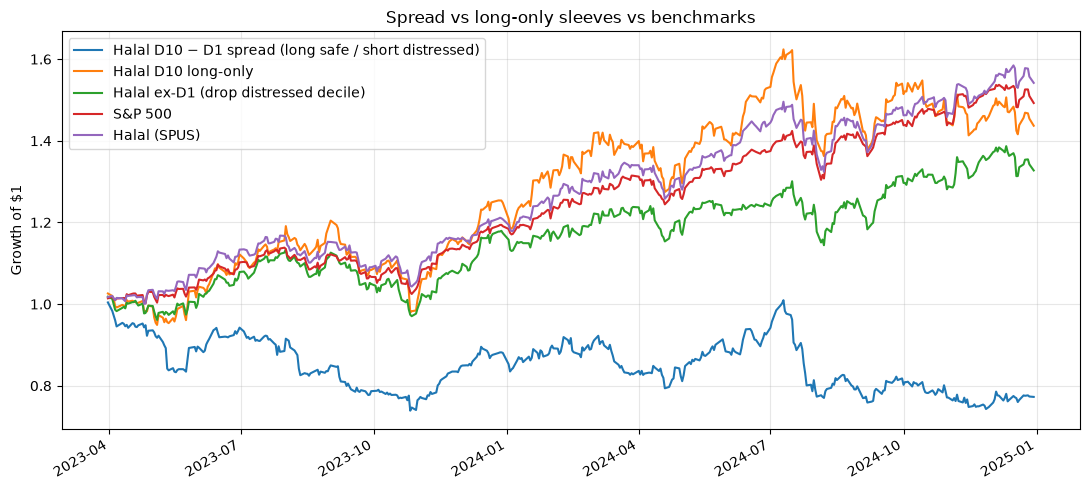

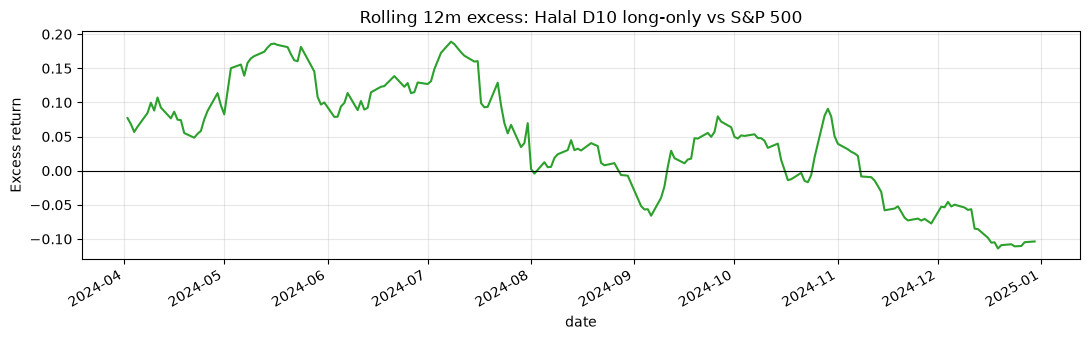

In [8]:

def benchmark_returns(ticker: str) -> pd.Series:
    px = prices[prices["symbol"] == ticker].copy()
    px["date"] = pd.to_datetime(px["date"])
    px = px.sort_values("date").set_index("date")["adj_close"]
    return px.pct_change(fill_method=None).dropna()


def align_to_live(strategy: pd.Series, benches: dict[str, pd.Series]) -> pd.DataFrame:
    strategy = strategy.copy()
    strategy.index = pd.to_datetime(strategy.index)
    panel_out = pd.DataFrame({"strategy": strategy})
    for name, series in benches.items():
        s = series.copy()
        s.index = pd.to_datetime(s.index)
        panel_out[name] = s
    return panel_out.dropna(how="any")


stock_returns = (
    prices[prices["symbol"].isin(eligible_universe)]
    .pivot(index="date", columns="symbol", values="adj_close")
    .sort_index()
    .ffill()
    .pct_change(fill_method=None)
)

long_only = halal_d10.copy()
long_only.name = LONG_ONLY_LABEL
exclude_d1 = exclude_decile_returns(snapshots, stock_returns, cohort="halal", drop_decile=1)
exclude_d1.name = EXCLUDE_D1_LABEL
halal_ew = halal_equal_weight_returns(snapshots, stock_returns, cohort="halal")
halal_ew.name = HALAL_EW_LABEL

bench_series = {name: benchmark_returns(ticker) for name, ticker in BENCHMARKS.items()}
main_panel = align_to_live(halal_spread, bench_series).rename(columns={"strategy": SPREAD_HALAL_LABEL})
non_panel = align_to_live(non_spread, bench_series).rename(columns={"strategy": SPREAD_NON_HALAL_LABEL})

long_panel = align_to_live(long_only, bench_series).rename(columns={"strategy": LONG_ONLY_LABEL})
excl_panel = align_to_live(exclude_d1, bench_series).rename(columns={"strategy": EXCLUDE_D1_LABEL})

if main_panel.empty:
    raise RuntimeError("No live days — re-run backtest cells.")

print(f"Live window: {main_panel.index.min().date()} → {main_panel.index.max().date()} ({len(main_panel)} days)")

rows = [
    calc_performance_stats(main_panel[SPREAD_HALAL_LABEL], SPREAD_HALAL_LABEL),
    calc_performance_stats(long_panel[LONG_ONLY_LABEL], LONG_ONLY_LABEL),
    calc_performance_stats(excl_panel[EXCLUDE_D1_LABEL], EXCLUDE_D1_LABEL),
    calc_performance_stats(halal_ew.reindex(main_panel.index).dropna(), HALAL_EW_LABEL),
]
if not non_panel.empty:
    rows.insert(1, calc_performance_stats(non_panel[SPREAD_NON_HALAL_LABEL], SPREAD_NON_HALAL_LABEL))
halal_d1_live = halal_d1.reindex(main_panel.index).dropna()
if not halal_d1_live.empty:
    d1_label = halal_d1_live.name if halal_d1_live.name not in (None, "return") else "Halal D1 (distressed)"
    rows.append(calc_performance_stats(halal_d1_live, d1_label))
for name in BENCHMARKS:
    rows.append(calc_performance_stats(main_panel[name], name))

performance = pd.DataFrame(rows).set_index("Strategy")
display(performance.style.format(formatters))

plot_panel = main_panel[[SPREAD_HALAL_LABEL]].copy()
plot_panel[LONG_ONLY_LABEL] = long_panel[LONG_ONLY_LABEL]
plot_panel[EXCLUDE_D1_LABEL] = excl_panel[EXCLUDE_D1_LABEL]
for name in BENCHMARKS:
    plot_panel[name] = main_panel[name]

equity_curves = (1 + plot_panel).cumprod()
equity_curves.plot(figsize=(11, 5), title="Spread vs long-only sleeves vs benchmarks")
plt.ylabel("Growth of $1")
plt.xlabel("")
save_fig("equity-curves-long-only.png")

if "S&P 500" in main_panel.columns:
    rolling_excess = (
        (1 + long_panel[LONG_ONLY_LABEL]).rolling(252).apply(np.prod, raw=True)
        - (1 + main_panel["S&P 500"]).rolling(252).apply(np.prod, raw=True)
    )
    rolling_excess.plot(figsize=(11, 3.5), color="tab:green", title="Rolling 12m excess: Halal D10 long-only vs S&P 500")
    plt.axhline(0, color="black", linewidth=0.8)
    plt.ylabel("Excess return")
    save_fig("rolling-excess-long-only.png")


## Step 9 — Regime analysis, drawdowns, decile monotonicity

- **Regime tables** — spread, D10 long-only, D1 by hike / cut / risk-on / neutral
- **SC_risk buffer** — median Halal vs Non-Halal `SC_risk` over time
- **Conditional decile monotonicity** — D1→D10 CAGR in each regime

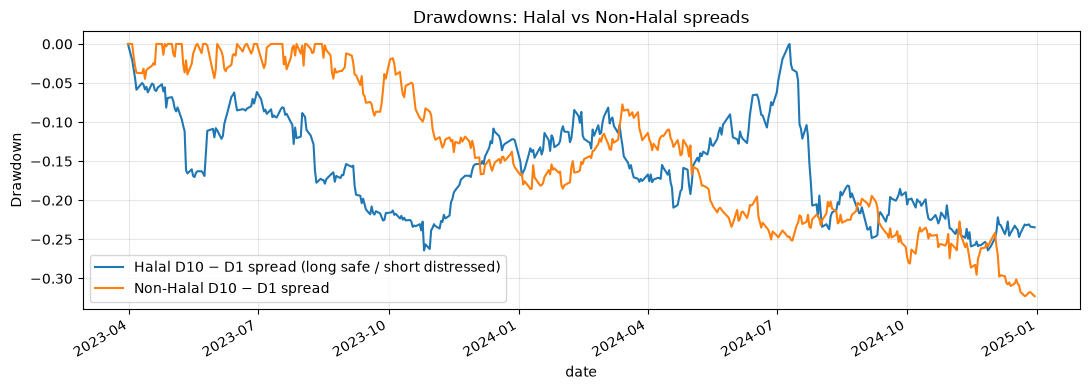

Regime breakdown — Halal spread (long D10 / short D1)


,Strategy,CAGR,Volatility,Sharpe,Sortino,Max Drawdown,Calmar,Skew,Kurtosis,Days
Regime,,,,,,,,,,
rate_hike,Halal D10 − D1 spread (long safe / short distressed),-31.00%,20.26%,-1.83,-2.40,-17.03%,-1.82,-0.52,4.29,83
risk_on,Halal D10 − D1 spread (long safe / short distressed),-9.14%,21.08%,-0.44,-0.62,-26.41%,-0.35,-0.45,1.43,357


Regime breakdown — Halal D10 long-only


,Strategy,CAGR,Volatility,Sharpe,Sortino,Max Drawdown,Calmar,Skew,Kurtosis,Days
Regime,,,,,,,,,,
rate_hike,Halal D10 long-only,55.22%,19.90%,2.21,4.32,-7.50%,7.36,0.41,0.37,83
risk_on,Halal D10 long-only,16.61%,22.07%,0.72,1.01,-18.66%,0.89,-0.36,1.10,357


Regime breakdown — Halal D1 (distressed leg)


,Strategy,CAGR,Volatility,Sharpe,Sortino,Max Drawdown,Calmar,Skew,Kurtosis,Days
Regime,,,,,,,,,,
rate_hike,Halal D1 (distressed),121.11%,17.55%,4.50,7.80,-3.90%,31.05,0.60,2.64,83
risk_on,Halal D1 (distressed),27.18%,14.91%,1.55,2.41,-7.75%,3.51,0.22,3.82,357


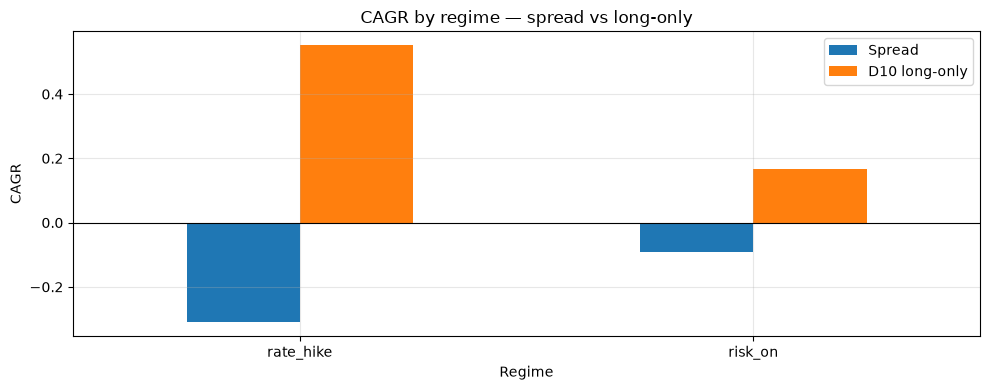

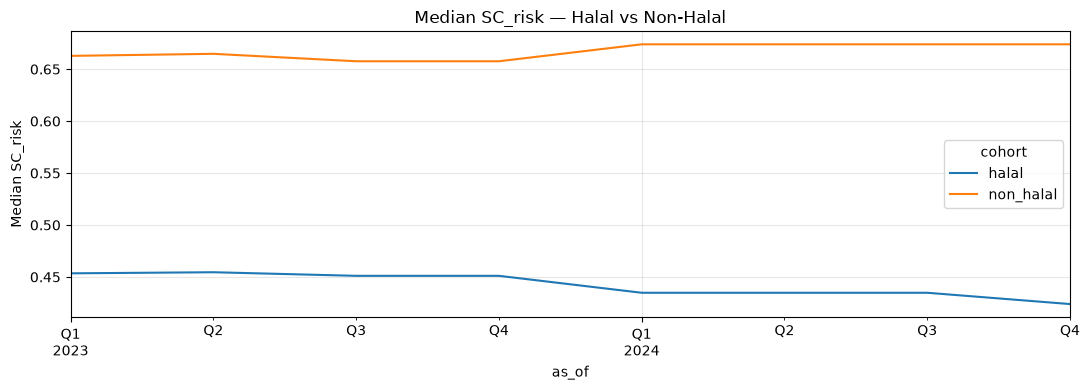

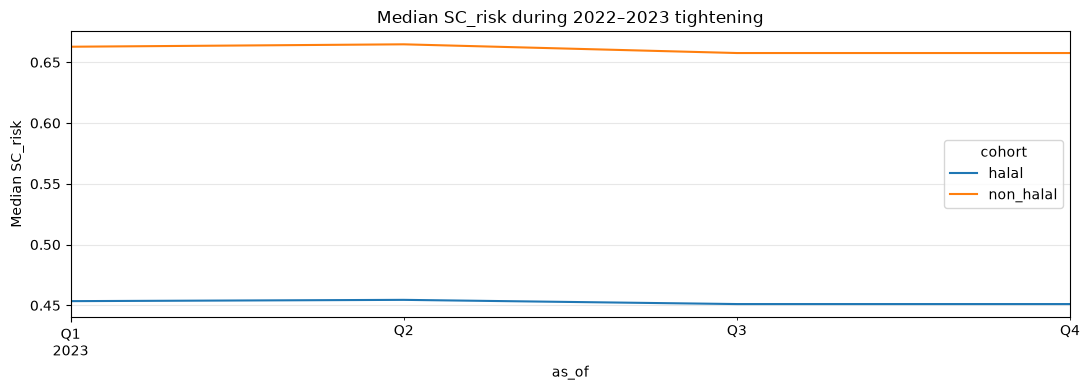

,CAGR,Max Drawdown,Sharpe,Skew
Strategy,,,,
halal_D1,41.17%,-7.75%,2.18,0.35
halal_D2,22.57%,-17.73%,1.05,0.50
halal_D3,6.36%,-19.18%,0.32,-0.28
halal_D4,17.15%,-10.97%,0.94,-0.36
halal_D5,23.07%,-18.66%,0.97,-0.26
non_halal_D1,-0.15%,-30.05%,-0.00,-0.37
non_halal_D2,-2.08%,-21.35%,-0.14,-0.12
non_halal_D3,-1.38%,-22.85%,-0.04,0.25
non_halal_D4,-2.20%,-21.25%,-0.16,-0.12


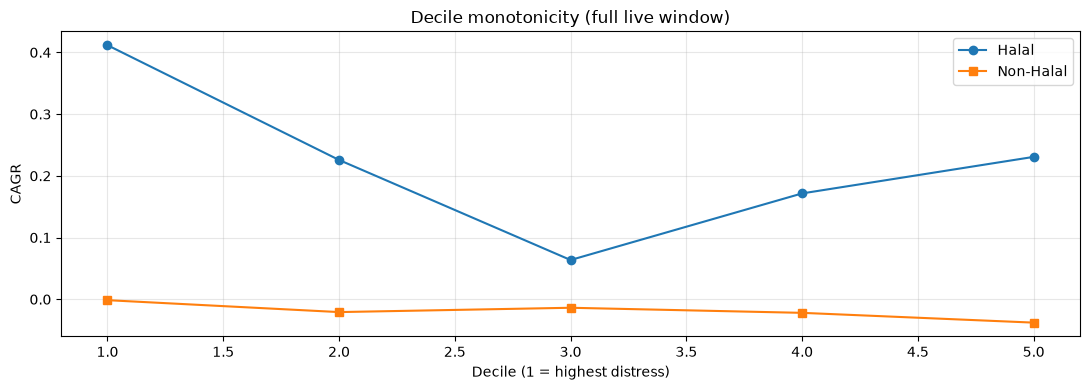

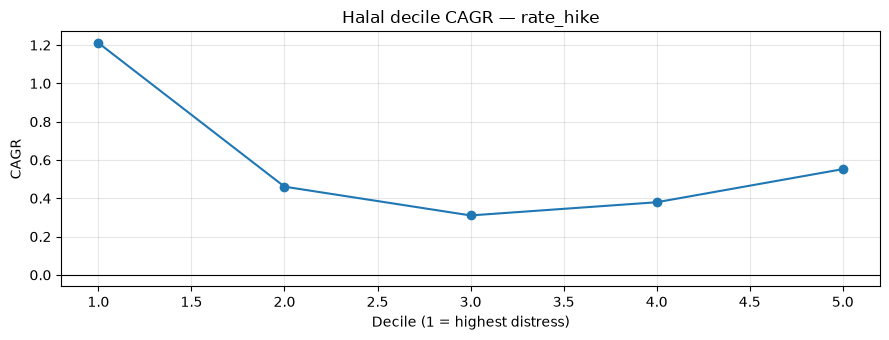

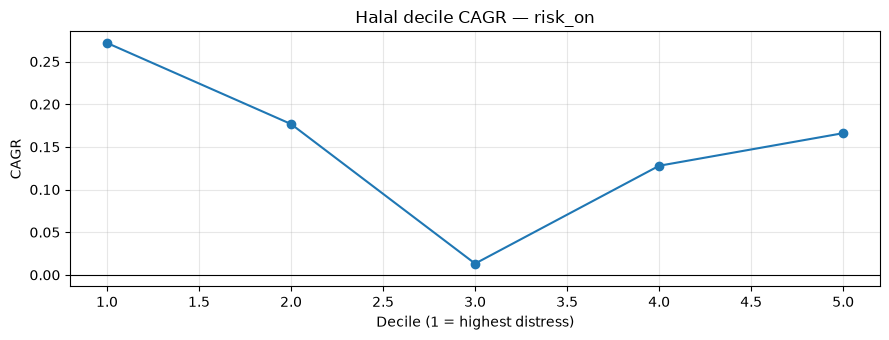

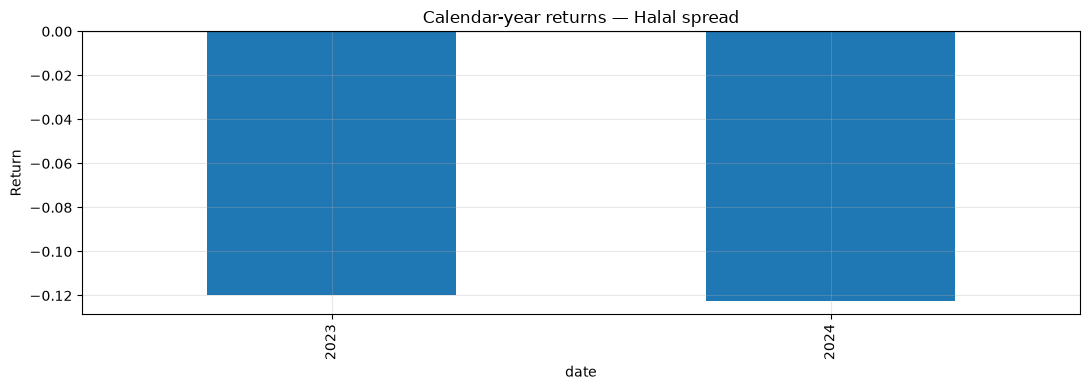

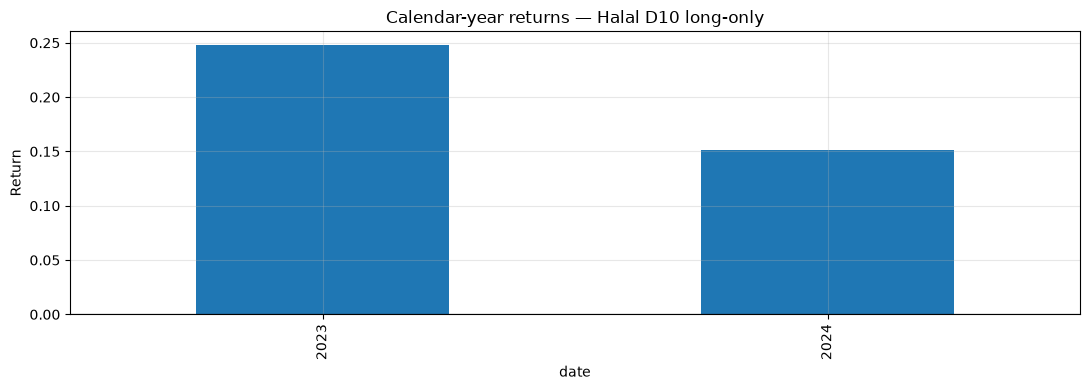

In [9]:

spread_panel = pd.DataFrame({
    SPREAD_HALAL_LABEL: halal_spread,
    SPREAD_NON_HALAL_LABEL: non_spread,
}).dropna(how="all").reindex(main_panel.index)

drawdowns = (1 + spread_panel).cumprod()
drawdowns = drawdowns / drawdowns.cummax() - 1
drawdowns.plot(figsize=(11, 4), title="Drawdowns: Halal vs Non-Halal spreads")
plt.ylabel("Drawdown")
save_fig("drawdowns.png")

# --- Regime performance tables ---
print("Regime breakdown — Halal spread (long D10 / short D1)")
display(regime_table(main_panel[SPREAD_HALAL_LABEL], SPREAD_HALAL_LABEL).style.format(formatters))

print("Regime breakdown — Halal D10 long-only")
display(regime_table(long_panel[LONG_ONLY_LABEL], LONG_ONLY_LABEL).style.format(formatters))

if not halal_d1_live.empty:
    print("Regime breakdown — Halal D1 (distressed leg)")
    display(regime_table(halal_d1_live, d1_label).style.format(formatters))

# Bar chart: spread CAGR by regime
spread_reg = regime_table(main_panel[SPREAD_HALAL_LABEL], SPREAD_HALAL_LABEL)
long_reg = regime_table(long_panel[LONG_ONLY_LABEL], LONG_ONLY_LABEL)
if not spread_reg.empty and not long_reg.empty:
    cmp = pd.DataFrame({
        "Spread": spread_reg["CAGR"],
        "D10 long-only": long_reg["CAGR"],
    })
    cmp.plot(kind="bar", figsize=(10, 4), title="CAGR by regime — spread vs long-only")
    plt.ylabel("CAGR")
    plt.axhline(0, color="black", linewidth=0.8)
    plt.xticks(rotation=0)
    save_fig("regime-cagr-bars.png")

# SC_risk buffer over time
if not snapshots.empty:
    med = snapshots.groupby(["as_of", "cohort"])["sc_risk"].median().unstack()
    med.index = pd.to_datetime(med.index)
    med.plot(figsize=(11, 4), title="Median SC_risk — Halal vs Non-Halal")
    plt.ylabel("Median SC_risk")
    save_fig("sc-risk-buffer.png")

    hike_snaps = snapshots[pd.to_datetime(snapshots["as_of"]).between("2022-01-01", "2023-12-31")]
    if not hike_snaps.empty:
        med_hike = hike_snaps.groupby(["as_of", "cohort"])["sc_risk"].median().unstack()
        med_hike.index = pd.to_datetime(med_hike.index)
        med_hike.plot(figsize=(11, 4), title="Median SC_risk during 2022–2023 tightening")
        plt.ylabel("Median SC_risk")
        save_fig("sc-risk-hike-cycle.png")

# Decile monotonicity (full sample)
decile_live = decile_returns.reindex(main_panel.index)
decile_stats = []
for col in decile_live.columns:
    decile_stats.append(calc_performance_stats(decile_live[col].dropna(), col))
decile_perf = pd.DataFrame(decile_stats).set_index("Strategy")
display(decile_perf[["CAGR", "Max Drawdown", "Sharpe", "Skew"]].style.format(formatters))

halal_cagrs = [decile_perf.loc[f"halal_D{d}", "CAGR"] for d in range(1, N_DECILES + 1) if f"halal_D{d}" in decile_perf.index]
non_cagrs = [decile_perf.loc[f"non_halal_D{d}", "CAGR"] for d in range(1, N_DECILES + 1) if f"non_halal_D{d}" in decile_perf.index]
fig, ax = plt.subplots(figsize=(11, 4))
if halal_cagrs:
    ax.plot(range(1, len(halal_cagrs) + 1), halal_cagrs, marker="o", label="Halal")
if non_cagrs:
    ax.plot(range(1, len(non_cagrs) + 1), non_cagrs, marker="s", label="Non-Halal")
ax.set_xlabel("Decile (1 = highest distress)")
ax.set_ylabel("CAGR")
ax.set_title("Decile monotonicity (full live window)")
ax.legend()
save_fig("decile-monotonicity.png")

# Conditional decile monotonicity by regime
for regime_name in ["rate_hike", "risk_on", "neutral"]:
    days = [d for d in decile_live.index if classify_regime(d) == regime_name]
    if len(days) < 60:
        continue
    sub = decile_live.reindex(days).dropna(how="all", axis=1)
    if sub.empty:
        continue
    cagrs = []
    for d in range(1, N_DECILES + 1):
        col = f"halal_D{d}"
        if col in sub.columns and sub[col].notna().any():
            cagrs.append(calc_performance_stats(sub[col].dropna(), col)["CAGR"])
        else:
            cagrs.append(np.nan)
    if cagrs:
        plt.figure(figsize=(9, 3.5))
        plt.plot(range(1, len(cagrs) + 1), cagrs, marker="o")
        plt.axhline(0, color="black", linewidth=0.8)
        plt.title(f"Halal decile CAGR — {regime_name}")
        plt.xlabel("Decile (1 = highest distress)")
        plt.ylabel("CAGR")
        save_fig(f"decile-monotonicity-{regime_name}.png")

yearly = (1 + main_panel[SPREAD_HALAL_LABEL]).resample("YE").prod() - 1
yearly.index = yearly.index.year
yearly.plot(kind="bar", figsize=(11, 4), title="Calendar-year returns — Halal spread")
plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("Return")
save_fig("calendar-year-spread.png")

yearly_lo = (1 + long_panel[LONG_ONLY_LABEL]).resample("YE").prod() - 1
yearly_lo.index = yearly_lo.index.year
yearly_lo.plot(kind="bar", figsize=(11, 4), title="Calendar-year returns — Halal D10 long-only")
plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("Return")
save_fig("calendar-year-long-only.png")


## Step 10 — Attribution: alpha, beta, sector tilt

CAPM stats for **Halal D10 long-only** (primary sleeve) vs SPY and SPUS.

,Alpha (ann.),Beta,R²,Tracking error,Information ratio
Benchmark,,,,,
S&P 500,-10.91%,1.48,0.69,13.38%,-0.04
Halal (SPUS),-9.60%,1.29,0.75,11.54%,-0.24


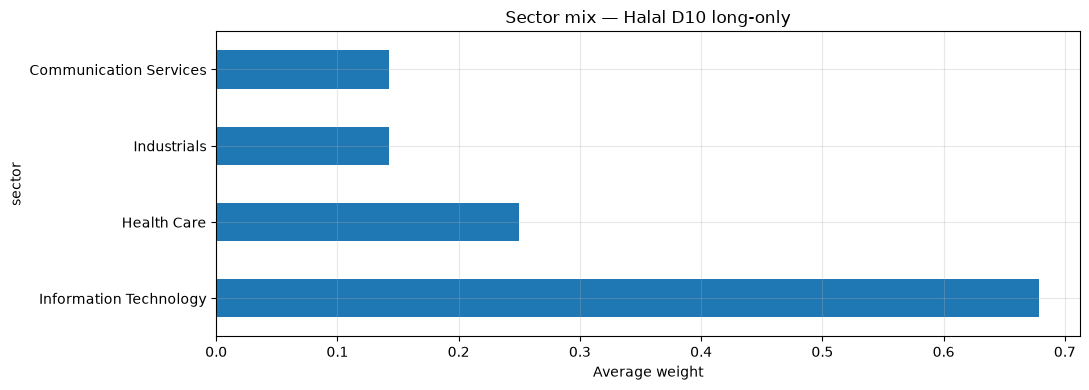

In [10]:

def capm_attribution(strategy: pd.Series, benchmark: pd.Series, rf: float = RISK_FREE_RATE) -> dict:
    aligned = pd.concat([strategy, benchmark], axis=1, keys=["y", "x"]).dropna()
    rf_d = rf / 252
    ye = aligned["y"] - rf_d
    xe = aligned["x"] - rf_d
    var_x = xe.var()
    beta = float(ye.cov(xe) / var_x) if var_x > 0 else np.nan
    alpha_d = float(ye.mean() - beta * xe.mean()) if pd.notna(beta) else np.nan
    resid = ye - alpha_d - beta * xe
    r2 = 1 - resid.var() / ye.var() if ye.var() > 0 else np.nan
    excess = aligned["y"] - aligned["x"]
    te = float(excess.std() * np.sqrt(252))
    ir = float(excess.mean() * 252 / te) if te > 0 else np.nan
    return {
        "Alpha (ann.)": alpha_d * 252,
        "Beta": beta,
        "R²": r2,
        "Tracking error": te,
        "Information ratio": ir,
    }


attr_rows = []
for bench_name in BENCHMARKS:
    row = capm_attribution(long_panel[LONG_ONLY_LABEL], long_panel[bench_name])
    row["Benchmark"] = bench_name
    attr_rows.append(row)
attr = pd.DataFrame(attr_rows).set_index("Benchmark")
display(
    attr.style.format({
        "Alpha (ann.)": "{:.2%}",
        "Beta": "{:.2f}",
        "R²": "{:.2f}",
        "Tracking error": "{:.2%}",
        "Information ratio": "{:.2f}",
    }).set_caption("Halal D10 long-only vs benchmarks")
)

if not snapshots.empty:
    gics_map = gics["gics_sector"].to_dict()
    d10_snaps = snapshots[(snapshots["cohort"] == "halal") & (snapshots["decile"] == N_DECILES)]
    month_weights = []
    for as_of, snap in d10_snaps.groupby("as_of"):
        w = 1.0 / len(snap)
        month_weights.append(
            snap.assign(weight=w)
            .assign(sector=lambda d: d["symbol"].map(gics_map).fillna("Unclassified"))
            .groupby("sector")["weight"]
            .sum()
        )
    if month_weights:
        sector_mix = pd.concat(month_weights, axis=1).mean(axis=1).sort_values(ascending=False)
        sector_mix.plot(kind="barh", figsize=(11, max(4, 0.35 * len(sector_mix))), title="Sector mix — Halal D10 long-only")
        plt.xlabel("Average weight")
        save_fig("sector-mix.png")


## Step 11 — Friction: turnover, trading costs

Turnover and cost drag on **Halal D10 long-only** (implementable sleeve).

Item,Value
Rebalances with D10 holdings,8
Average names in Halal D10,7.0
Annualized one-way turnover,32.7%
Assumed cost per one-way trade,10 bps
CAGR gross of trading costs,23.07%
CAGR net of trading costs,22.97%


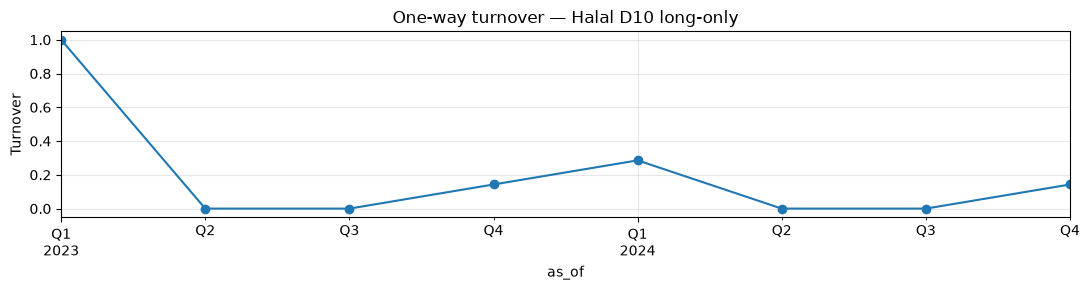

Fetching dividend purification for held names …


,symbol,ex_date,dividend,adj_dividend,record_date,payment_date,report_date,total_revenue,non_compliant_income,impure_ratio,purification_amount
0,A,2023-04-03,0.225,0.225,NaT,NaT,2022-10-31,6.848000e+09,9.000000e+06,0.001314,0.000296
1,A,2023-06-30,0.225,0.225,NaT,NaT,2022-10-31,6.848000e+09,9.000000e+06,0.001314,0.000296
2,A,2023-10-02,0.225,0.225,NaT,NaT,2022-10-31,6.848000e+09,9.000000e+06,0.001314,0.000296
3,A,2023-12-29,0.236,0.236,NaT,NaT,2022-10-31,6.848000e+09,9.000000e+06,0.001314,0.000310
4,A,2024-04-01,0.236,0.236,NaT,NaT,2023-10-31,6.833000e+09,5.100000e+07,0.007464,0.001761
5,A,2024-07-02,0.236,0.236,NaT,NaT,2023-10-31,6.833000e+09,5.100000e+07,0.007464,0.001761
6,A,2024-10-01,0.236,0.236,NaT,NaT,2023-10-31,6.833000e+09,5.100000e+07,0.007464,0.001761
7,A,2024-12-31,0.248,0.248,NaT,NaT,2023-10-31,6.833000e+09,5.100000e+07,0.007464,0.001851
8,AAPL,2023-05-12,0.240,0.240,NaT,NaT,2022-09-30,3.943280e+11,2.825000e+09,0.007164,0.001719
9,AAPL,2023-08-11,0.240,0.240,NaT,NaT,2022-09-30,3.943280e+11,2.825000e+09,0.007164,0.001719


In [11]:

def one_way_turnover(old: dict[str, float], new: dict[str, float]) -> float:
    if not new:
        return 0.0
    if not old:
        return 1.0
    names = set(old) | set(new)
    return 0.5 * sum(abs(new.get(s, 0.0) - old.get(s, 0.0)) for s in names)


def turnover_from_weights(weights_by_date: dict[date, pd.Series]) -> pd.DataFrame:
    rows = []
    prev: dict[str, float] = {}
    for as_of in sorted(weights_by_date):
        w = weights_by_date[as_of]
        curr = w.to_dict() if not w.empty else {}
        rows.append({"as_of": pd.Timestamp(as_of), "one_way": one_way_turnover(prev, curr), "n": len(curr)})
        prev = curr
    return pd.DataFrame(rows).set_index("as_of")


halal_d10_weights: dict[date, pd.Series] = {}
if not snapshots.empty:
    for as_of, snap in snapshots[(snapshots["cohort"] == "halal") & (snapshots["decile"] == N_DECILES)].groupby("as_of"):
        chunk = snap
        if not chunk.empty:
            halal_d10_weights[as_of] = pd.Series(1.0 / len(chunk), index=chunk["symbol"].values)

turnover = turnover_from_weights(halal_d10_weights)
quarters = max(len(turnover) - 1, 1)
annual_turnover = turnover["one_way"].iloc[1:].sum() * (4 / quarters) if len(turnover) > 1 else np.nan
cost_drag_ann = annual_turnover * COST_BPS / 10_000

cost_on_day = pd.Series(0.0, index=long_panel.index)
for as_of, row in turnover.iterrows():
    hit = long_panel.index[long_panel.index >= as_of]
    if len(hit):
        cost_on_day.loc[hit[0]] += float(row["one_way"]) * COST_BPS / 10_000

net_returns = long_panel[LONG_ONLY_LABEL] - cost_on_day
net_stats = calc_performance_stats(net_returns, f"{LONG_ONLY_LABEL} net of {COST_BPS} bps")
gross_cagr = calc_performance_stats(long_panel[LONG_ONLY_LABEL], LONG_ONLY_LABEL)["CAGR"]

friction = pd.DataFrame({
    "Item": [
        "Rebalances with D10 holdings",
        "Average names in Halal D10",
        "Annualized one-way turnover",
        "Assumed cost per one-way trade",
        "CAGR gross of trading costs",
        "CAGR net of trading costs",
    ],
    "Value": [
        f"{len(turnover)}",
        f"{turnover['n'].mean():.1f}",
        f"{annual_turnover:.1%}",
        f"{COST_BPS} bps",
        f"{gross_cagr:.2%}",
        f"{net_stats['CAGR']:.2%}",
    ],
})
display(friction.style.hide(axis="index"))

turnover["one_way"].plot(figsize=(11, 3), marker="o", title="One-way turnover — Halal D10 long-only")
plt.ylabel("Turnover")
save_fig("turnover.png")

held_symbols = sorted(snapshots["symbol"].unique()) if not snapshots.empty else []
if held_symbols:
    print("Fetching dividend purification for held names …")
    try:
        purified = hq.purify_dividends(held_symbols, start=str(long_panel.index.min().date()), end=END)
        if purified.empty:
            print("No purification rows — report as data gap.")
        else:
            display(purified.head(10))
    except Exception as exc:
        print(f"Purification lookup failed ({exc}).")


### Notes on methodology

- **code2 vs code:** Extended `START` (2015), `figures2/`, Merton DD clip, regime tables, long-only sleeves.
- **Regimes:** Calendar buckets (hike / cut / risk-on / neutral) — not a trading signal.
- **Investable sleeve:** **Halal D10 long-only**; spread is research-only.
- **Deciles:** D1 = highest `SC_risk`, D10 = lowest.
- **White-paper map:** Step 8–9 → section 3 (regime-conditioned); Step 10 → section 4; Step 11 → section 5.

## Summary

1. **Buffer hypothesis** — compare median `SC_risk` Halal vs Non-Halal, especially in **rate_hike** regimes.
2. **Factor hypothesis** — decile monotonicity and spread returns are **regime-conditional**; expect weak spreads in **risk_on**.
3. **Product** — judge **Halal D10 long-only** vs SPUS, not the short leg spread alone.